# Ejercicio 12: Multimodal Embeddings

## Objetivo de la práctica

El objetivo de este ejercicio es observar cómo modelos multimodales como CLIP llevan texto e imágenes al mismo espacio vectorial, y verificar graficando embeddings en 2D.

### Pasos:

1. Obtener embeddings de imágenes y textos con CLIP.
2. Mostrar que ambos viven en el mismo espacio (misma dimensión y comparables).
3. Proyectar los vectores a 2D (PCA / t-SNE / UMAP) y graficarlos en un plano.
4. Verificar emparejamientos usando cosine similarity (búsqueda texto→imagen e imagen→texto).

## 1. Instalación de dependencias

In [1]:
!uv pip install scikit-image pillow matplotlib --quiet

## 2. Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from skimage import data as skdata
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch
from transformers import CLIPProcessor, CLIPModel

/home/migueldev/Documents/University/Courses/RI/Practices/recuperacion_de_informacion/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Carga del modelo CLIP

Usamos `openai/clip-vit-base-patch32` — el modelo original de OpenAI, disponible en HuggingFace.  
Produce embeddings de 512 dimensiones tanto para imágenes como para texto.

In [6]:
# Configurar dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo disponible: {device}')

Dispositivo disponible: cuda


In [7]:
model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_name).to(device)
processor = CLIPProcessor.from_pretrained(model_name)
model.eval()

emb_dim = model.config.projection_dim
print(f"Dimensión de embedding CLIP: {emb_dim}")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 53643.53it/s]


Dimensión de embedding CLIP: 512


## 4. Preparación de imágenes y textos

Usamos las imágenes de muestra integradas en `scikit-image`
Definimos textos que coinciden semánticamente con cada imagen, más algunos **distractores**.

In [8]:
# Imágenes de scikit-image
raw_images_rgb = {
    "astronaut": skdata.astronaut(),
    "cat (Chelsea)": skdata.chelsea(),
    "coffee": skdata.coffee()[..., :3],
    "rocket": skdata.rocket(),
}

pil_images = {name: Image.fromarray(arr) for name, arr in raw_images_rgb.items()}
img_labels = list(pil_images.keys())

# Textos: 4 matching (uno por imagen) + 3 distractores
texts_matching = [
    "an astronaut wearing a white spacesuit",
    "a tabby cat with green eyes",
    "a cup of coffee on a saucer",
    "a rocket launching into the sky",
]
texts_distractor = [
    "a dog playing fetch in the park",
    "snow-capped mountain peaks",
    "a red sports car on the road",
]
all_texts = texts_matching + texts_distractor
txt_labels = all_texts

print(f"Imágenes: {len(pil_images)}")
print(f"Textos totales: {len(all_texts)} ({len(texts_matching)} matching + {len(texts_distractor)} distractores)")

Imágenes: 4
Textos totales: 7 (4 matching + 3 distractores)


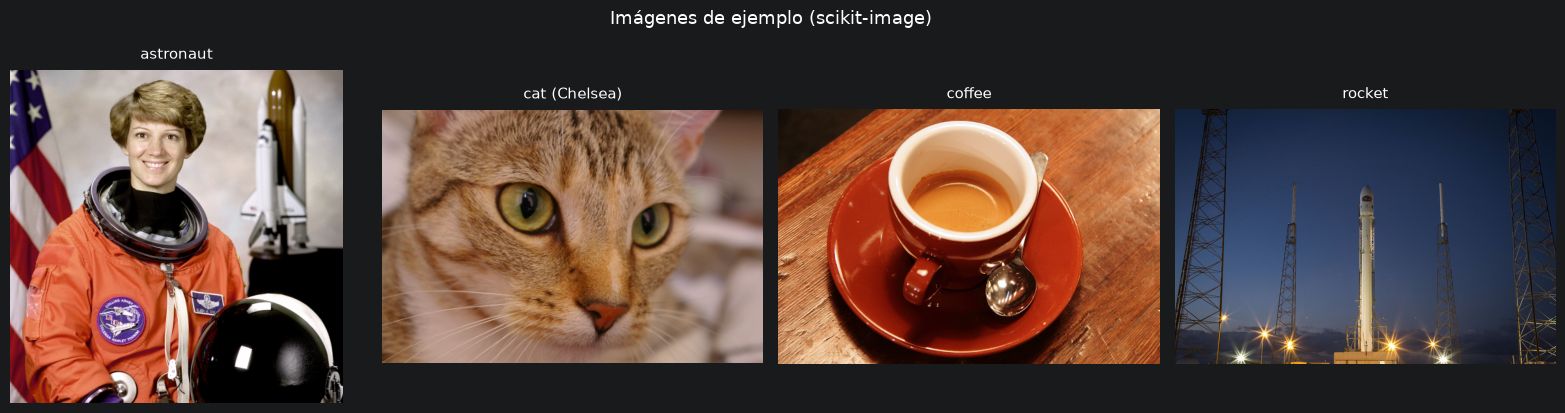

In [9]:
# Visualizar imágenes
fig, axes = plt.subplots(1, len(pil_images), figsize=(16, 4))
for ax, (name, img) in zip(axes, pil_images.items()):
    ax.imshow(img)
    ax.set_title(name, fontsize=11, pad=8)
    ax.axis('off')
plt.suptitle("Imágenes de ejemplo (scikit-image)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Extracción de embeddings con CLIP

CLIP mapea imágenes y textos al mismo espacio vectorial de 512 dimensiones.
Los vectores se normalizan a norma 1 (sobre la hiperesfera unitaria), por lo que la similitud coseno equivale al producto punto.

In [13]:
@torch.no_grad()
def embed_images(images: list) -> np.ndarray:
    inputs = processor(images=images, return_tensors="pt", padding=True).to(device)
    vision_out = model.vision_model(pixel_values=inputs["pixel_values"])
    feats = model.visual_projection(vision_out.pooler_output)
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu().numpy()

@torch.no_grad()
def embed_texts(texts: list) -> np.ndarray:
    inputs = processor(text=texts, return_tensors="pt", padding=True, truncation=True).to(device)
    text_out = model.text_model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"])
    feats = model.text_projection(text_out.pooler_output)
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu().numpy()

img_embs = embed_images(list(pil_images.values()))
txt_embs = embed_texts(all_texts)

print("=== Mismo espacio vectorial ===")
print(f"Embeddings imagen : {img_embs.shape}  → {img_embs.shape[1]}D")
print(f"Embeddings texto  : {txt_embs.shape}  → {txt_embs.shape[1]}D")
print(f"Misma dimensión   : {img_embs.shape[1] == txt_embs.shape[1]}")
print(f"Normas imagen (≈1): {np.linalg.norm(img_embs, axis=1).round(4)}")
print(f"Normas texto  (≈1): {np.linalg.norm(txt_embs, axis=1).round(4)}")

=== Mismo espacio vectorial ===
Embeddings imagen : (4, 512)  → 512D
Embeddings texto  : (7, 512)  → 512D
Misma dimensión   : True
Normas imagen (≈1): [1. 1. 1. 1.]
Normas texto  (≈1): [1. 1. 1. 1. 1. 1. 1.]


## 6. Matriz de similitud coseno (Textos × Imágenes)

Cada celda muestra cuán similar es un texto a una imagen en el espacio CLIP.  
Los valores **altos en la diagonal** confirman que los textos matching se alinean con su imagen correspondiente.

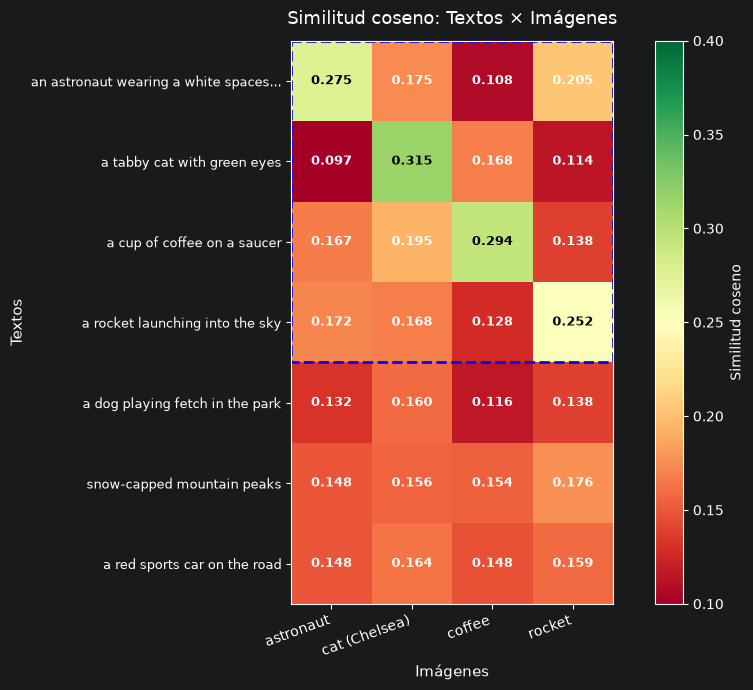

Zona azul = textos matching. Valores altos en diagonal ✓


In [14]:
sim_matrix = cosine_similarity(txt_embs, img_embs)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0.1, vmax=0.4)

# Etiquetas
short_txt = [t[:35] + "..." if len(t) > 35 else t for t in txt_labels]
ax.set_xticks(range(len(img_labels)))
ax.set_xticklabels(img_labels, rotation=20, ha='right', fontsize=10)
ax.set_yticks(range(len(short_txt)))
ax.set_yticklabels(short_txt, fontsize=9)

# Valores numéricos en cada celda
for i in range(len(txt_labels)):
    for j in range(len(img_labels)):
        val = sim_matrix[i, j]
        ax.text(j, i, f"{val:.3f}", ha='center', va='center', fontsize=9,
                color='white' if val < 0.22 else 'black', fontweight='bold')

# Marcar la zona de matching (4x4 cuadrado diagonal)
rect = plt.Rectangle((-0.5, -0.5), len(img_labels), len(texts_matching),
                      linewidth=2, edgecolor='blue', facecolor='none', linestyle='--')
ax.add_patch(rect)

plt.colorbar(im, ax=ax, label="Similitud coseno")
ax.set_title("Similitud coseno: Textos × Imágenes", fontsize=13, pad=12)
ax.set_xlabel("Imágenes", fontsize=11)
ax.set_ylabel("Textos", fontsize=11)
plt.tight_layout()
plt.show()

print("Zona azul = textos matching. Valores altos en diagonal ✓")

## 7. Proyección PCA a 2D

Reducimos los 512 ejes a 2 componentes principales.  
Los vectores de imagen (●) y texto (★/▲) deberían agruparse semánticamente — imagen y texto del mismo concepto quedan próximos.

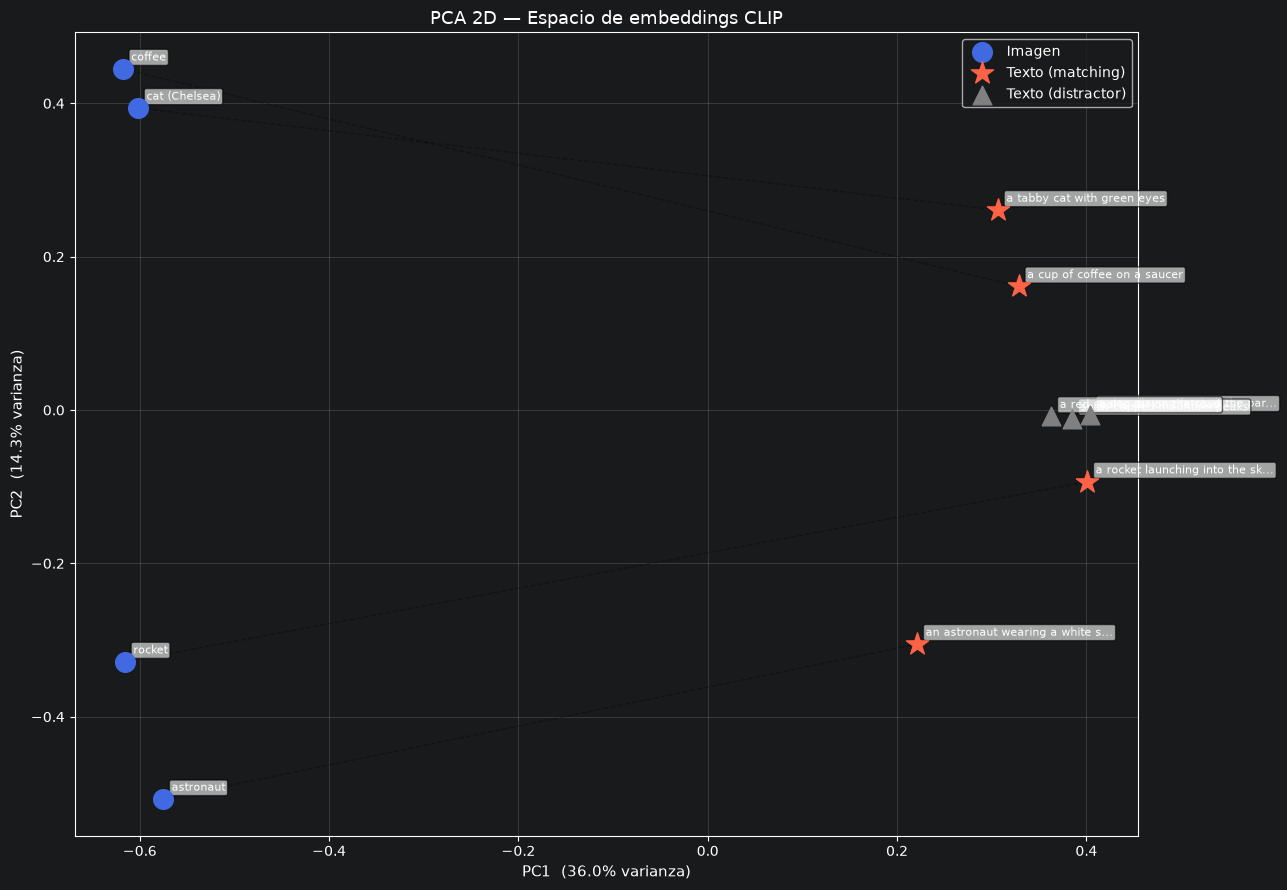

In [15]:
all_embs = np.vstack([img_embs, txt_embs])
n_img = len(img_labels)
n_match = len(texts_matching)

pca = PCA(n_components=2, random_state=42)
embs_2d_pca = pca.fit_transform(all_embs)

var1, var2 = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(13, 9))

# Imágenes
ax.scatter(embs_2d_pca[:n_img, 0], embs_2d_pca[:n_img, 1],
           c='royalblue', marker='o', s=200, zorder=5, label='Imagen')
# Textos matching
ax.scatter(embs_2d_pca[n_img:n_img+n_match, 0], embs_2d_pca[n_img:n_img+n_match, 1],
           c='tomato', marker='*', s=280, zorder=5, label='Texto (matching)')
# Textos distractores
ax.scatter(embs_2d_pca[n_img+n_match:, 0], embs_2d_pca[n_img+n_match:, 1],
           c='gray', marker='^', s=180, zorder=5, label='Texto (distractor)')

# Líneas img ↔ texto matching
for i in range(n_img):
    x_vals = [embs_2d_pca[i, 0], embs_2d_pca[n_img + i, 0]]
    y_vals = [embs_2d_pca[i, 1], embs_2d_pca[n_img + i, 1]]
    ax.plot(x_vals, y_vals, 'k--', alpha=0.3, linewidth=1)

# Etiquetas
all_labels = img_labels + [t[:30]+"..." if len(t)>30 else t for t in all_texts]
for i, lbl in enumerate(all_labels):
    ax.annotate(lbl, embs_2d_pca[i], fontsize=8,
                xytext=(6, 6), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))

ax.set_title("PCA 2D — Espacio de embeddings CLIP", fontsize=13)
ax.set_xlabel(f"PC1  ({var1:.1%} varianza)", fontsize=11)
ax.set_ylabel(f"PC2  ({var2:.1%} varianza)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Proyección t-SNE a 2D

t-SNE preserva mejor las distancias **locales** que PCA. Con pocos puntos (11) usamos `perplexity=3`.

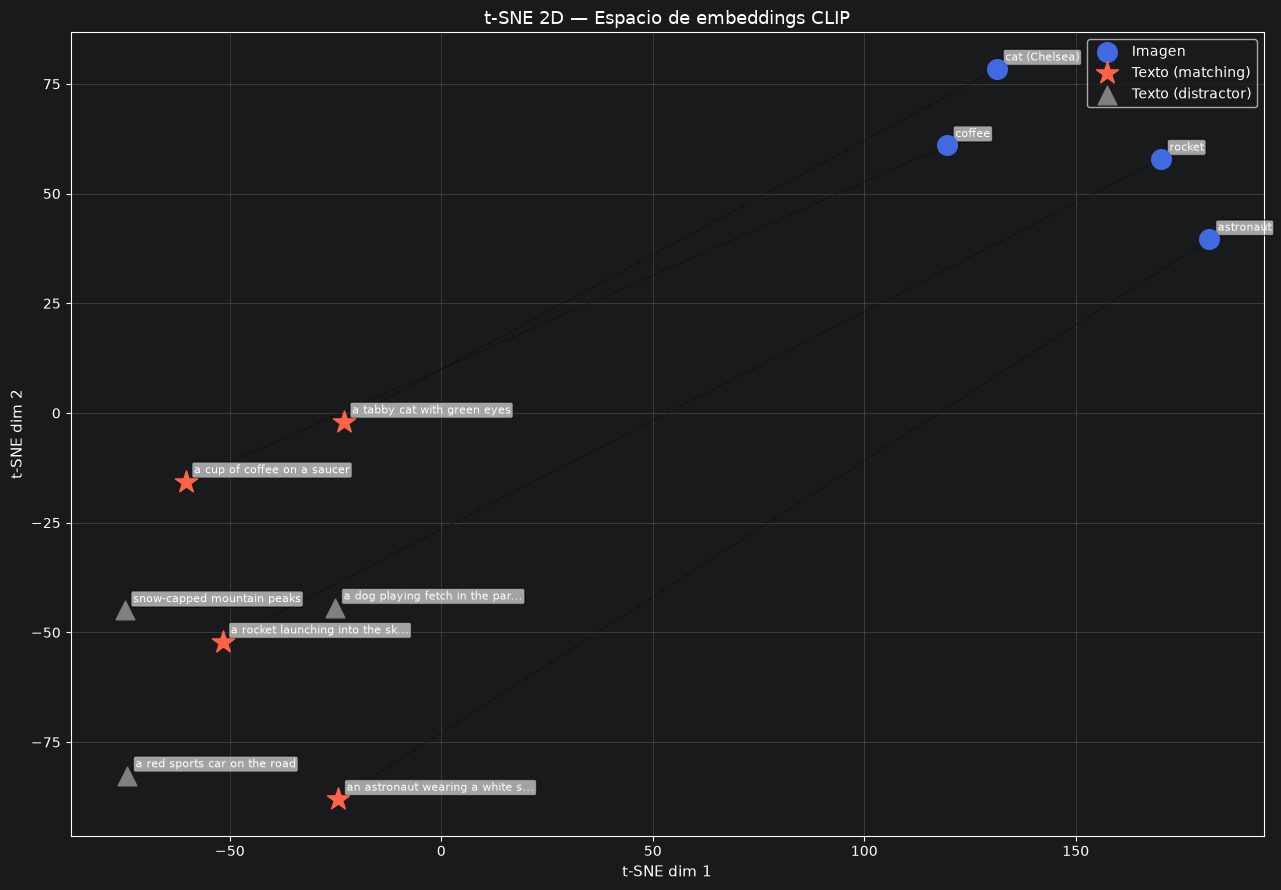

In [17]:
tsne = TSNE(n_components=2, perplexity=3, random_state=42, max_iter=2000, init='pca')
embs_2d_tsne = tsne.fit_transform(all_embs)  # (11, 2)

fig, ax = plt.subplots(figsize=(13, 9))

ax.scatter(embs_2d_tsne[:n_img, 0], embs_2d_tsne[:n_img, 1],
           c='royalblue', marker='o', s=200, zorder=5, label='Imagen')
ax.scatter(embs_2d_tsne[n_img:n_img+n_match, 0], embs_2d_tsne[n_img:n_img+n_match, 1],
           c='tomato', marker='*', s=280, zorder=5, label='Texto (matching)')
ax.scatter(embs_2d_tsne[n_img+n_match:, 0], embs_2d_tsne[n_img+n_match:, 1],
           c='gray', marker='^', s=180, zorder=5, label='Texto (distractor)')

for i in range(n_img):
    x_vals = [embs_2d_tsne[i, 0], embs_2d_tsne[n_img + i, 0]]
    y_vals = [embs_2d_tsne[i, 1], embs_2d_tsne[n_img + i, 1]]
    ax.plot(x_vals, y_vals, 'k--', alpha=0.3, linewidth=1)

for i, lbl in enumerate(all_labels):
    ax.annotate(lbl, embs_2d_tsne[i], fontsize=8,
                xytext=(6, 6), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))

ax.set_title("t-SNE 2D — Espacio de embeddings CLIP", fontsize=13)
ax.set_xlabel("t-SNE dim 1", fontsize=11)
ax.set_ylabel("t-SNE dim 2", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Búsqueda Texto → Imagen

Para cada consulta textual, recuperamos las imágenes ordenadas por similitud coseno.  
El resultado correcto debería aparecer en **posición 1** para los textos matching.

In [18]:
print("=" * 60)
print("BÚSQUEDA: Texto → Imagen")
print("=" * 60)

correct = 0
for i, query in enumerate(all_texts):
    scores = cosine_similarity(txt_embs[i:i+1], img_embs)[0]
    ranking = sorted(zip(img_labels, scores), key=lambda x: -x[1])
    top1 = ranking[0][0]

    is_matching = i < n_img
    expected = img_labels[i] if is_matching else "(distractor)"
    hit = is_matching and (top1 == img_labels[i])
    if hit:
        correct += 1

    print(f"\nQuery : '{query}'")
    print(f"Espera: {expected}")
    for rank, (img_name, score) in enumerate(ranking, 1):
        marker = " ✓" if (rank == 1 and hit) else (" ✗" if (rank == 1 and is_matching) else "")
        print(f"  #{rank}  {img_name:<20} sim={score:.4f}{marker}")

print(f"\nPrecisión @1 (textos matching): {correct}/{n_img} = {correct/n_img:.0%}")

BÚSQUEDA: Texto → Imagen

Query : 'an astronaut wearing a white spacesuit'
Espera: astronaut
  #1  astronaut            sim=0.2753 ✓
  #2  rocket               sim=0.2048
  #3  cat (Chelsea)        sim=0.1748
  #4  coffee               sim=0.1078

Query : 'a tabby cat with green eyes'
Espera: cat (Chelsea)
  #1  cat (Chelsea)        sim=0.3146 ✓
  #2  coffee               sim=0.1684
  #3  rocket               sim=0.1145
  #4  astronaut            sim=0.0973

Query : 'a cup of coffee on a saucer'
Espera: coffee
  #1  coffee               sim=0.2941 ✓
  #2  cat (Chelsea)        sim=0.1947
  #3  astronaut            sim=0.1669
  #4  rocket               sim=0.1378

Query : 'a rocket launching into the sky'
Espera: rocket
  #1  rocket               sim=0.2520 ✓
  #2  astronaut            sim=0.1718
  #3  cat (Chelsea)        sim=0.1681
  #4  coffee               sim=0.1280

Query : 'a dog playing fetch in the park'
Espera: (distractor)
  #1  cat (Chelsea)        sim=0.1596
  #2  rocket    

## 10. Búsqueda Imagen → Texto

Dirección inversa: dada una imagen, recuperamos los textos más similares.  
El texto matching correcto debería ser el más cercano (top-1).

In [19]:
print("=" * 60)
print("BÚSQUEDA: Imagen → Texto")
print("=" * 60)

correct = 0
for i, img_name in enumerate(img_labels):
    scores = cosine_similarity(img_embs[i:i+1], txt_embs)[0]
    ranking = sorted(zip(all_texts, scores), key=lambda x: -x[1])
    top1_text = ranking[0][0]
    expected_text = texts_matching[i]
    hit = top1_text == expected_text
    if hit:
        correct += 1

    print(f"\nImagen: '{img_name}'")
    print(f"Espera: '{expected_text}'")
    for rank, (text, score) in enumerate(ranking[:4], 1):
        is_correct = text == expected_text
        marker = " ✓" if (rank == 1 and hit) else (" ✗" if (rank == 1 and not hit) else (" [correcto]" if is_correct else ""))
        print(f"  #{rank}  sim={score:.4f}  '{text}'{marker}")

print(f"\nPrecisión @1 (imagen→texto): {correct}/{n_img} = {correct/n_img:.0%}")

BÚSQUEDA: Imagen → Texto

Imagen: 'astronaut'
Espera: 'an astronaut wearing a white spacesuit'
  #1  sim=0.2753  'an astronaut wearing a white spacesuit' ✓
  #2  sim=0.1718  'a rocket launching into the sky'
  #3  sim=0.1669  'a cup of coffee on a saucer'
  #4  sim=0.1482  'snow-capped mountain peaks'

Imagen: 'cat (Chelsea)'
Espera: 'a tabby cat with green eyes'
  #1  sim=0.3146  'a tabby cat with green eyes' ✓
  #2  sim=0.1947  'a cup of coffee on a saucer'
  #3  sim=0.1748  'an astronaut wearing a white spacesuit'
  #4  sim=0.1681  'a rocket launching into the sky'

Imagen: 'coffee'
Espera: 'a cup of coffee on a saucer'
  #1  sim=0.2941  'a cup of coffee on a saucer' ✓
  #2  sim=0.1684  'a tabby cat with green eyes'
  #3  sim=0.1545  'snow-capped mountain peaks'
  #4  sim=0.1477  'a red sports car on the road'

Imagen: 'rocket'
Espera: 'a rocket launching into the sky'
  #1  sim=0.2520  'a rocket launching into the sky' ✓
  #2  sim=0.2048  'an astronaut wearing a white spacesuit'
  

## 11. Conclusiones

1. Espacio compartido: CLIP mapea imágenes y textos a vectores de 512 dimensiones idénticas. No hay espacios separados imagen y texto comparten la misma geometría.

2. Comparabilidad directa: La similitud coseno entre un embedding de imagen y uno de texto es significativa. Pares semánticamente correctos tienen similitud mayor que los distractores.

3. Visualización 2D: Tanto PCA como t-SNE revelan que imagen+texto del mismo concepto quedan próximos en el plano 2D, mientras los distractores se alejan. Las líneas punteadas que los unen suelen ser cortas para los pares correctos.

4. Durante el entrenamiento, CLIP minimiza la distancia coseno entre pares (imagen, descripción) reales y la maximiza para pares aleatorios. Con 400M pares imagen-texto de internet, el modelo aprende representaciones semánticas robustas que generalizan a imágenes no vistas.